# Experiment No. 6 — Implementation and Comparative Analysis of Image Segmentation Techniques

* **Name:** Akshit Negi
* **Course & Branch:** B.TECH CSE
* **CUID:** CU24250214
* **SUBJECT:** Computer Vision Lab
* **SEM & Section:** 5th SEM, "B"

**Aim:** Implement and compare Global Thresholding, Otsu's Thresholding, Adaptive Thresholding, Watershed Segmentation, and K-Means Clustering for image segmentation.

Upload your own image in Step 1.

---

### Steps 1–2: Import libraries, upload image, preprocess (grayscale + Gaussian blur)

Saving jpeg(2) to jpeg(2)


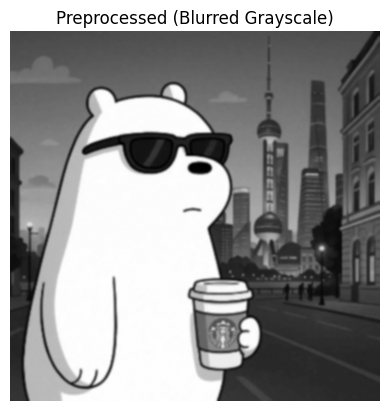

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()                        # choose an image from your laptop
img = cv2.imread(list(uploaded.keys())[0])
img = cv2.resize(img, (400, 400))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)       # noise reduction

plt.imshow(blurred, cmap='gray'); plt.title("Preprocessed (Blurred Grayscale)"); plt.axis('off'); plt.show()

### Steps 3–5: Global Thresholding, Otsu's Thresholding, Adaptive Thresholding

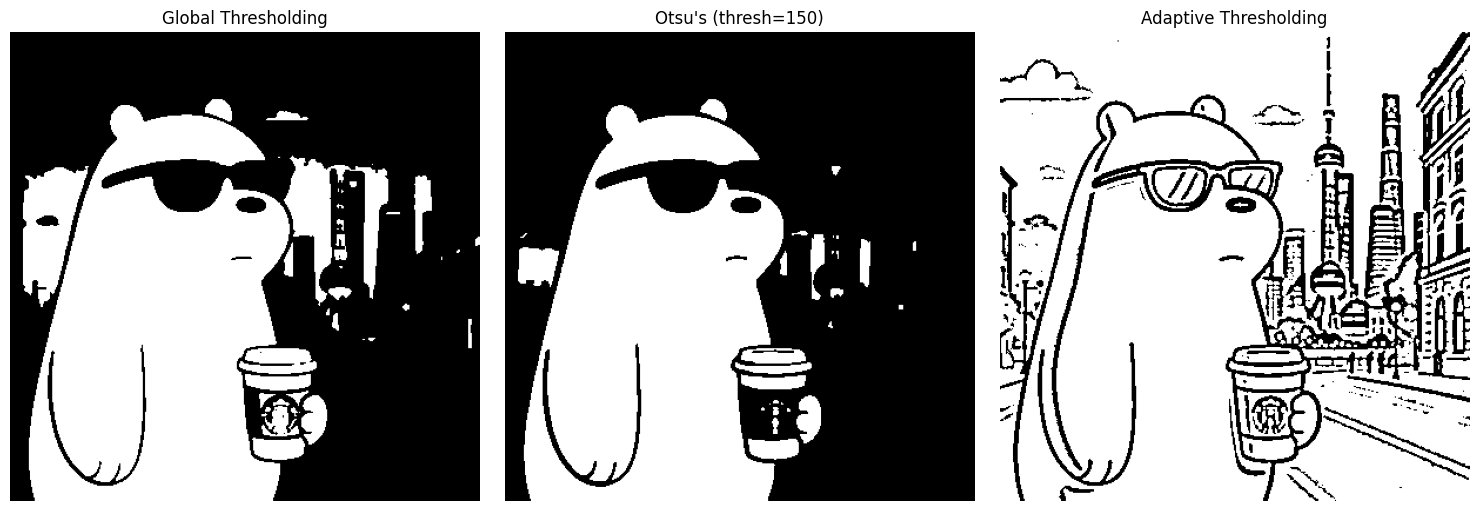

In [7]:
_, global_thresh = cv2.threshold(blurred, 127, 255, cv2.THRESH_BINARY)
otsu_val, otsu_thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
adaptive_thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                         cv2.THRESH_BINARY, 11, 2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(global_thresh, cmap='gray'); axes[0].set_title("Global Thresholding"); axes[0].axis('off')
axes[1].imshow(otsu_thresh, cmap='gray'); axes[1].set_title(f"Otsu's (thresh={otsu_val:.0f})"); axes[1].axis('off')
axes[2].imshow(adaptive_thresh, cmap='gray'); axes[2].set_title("Adaptive Thresholding"); axes[2].axis('off')
plt.tight_layout(); plt.show()

### Step 6: Watershed Segmentation

Separates touching/overlapping objects using distance transform + marker-based watershed.

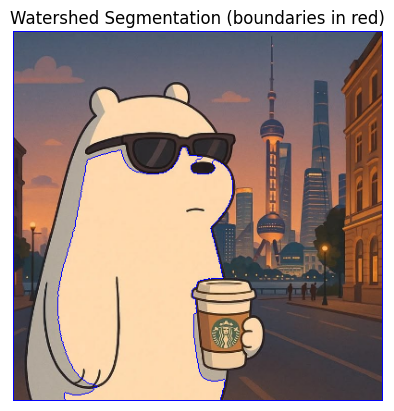

In [8]:
# Foreground/background estimation via Otsu + morphology
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(otsu_thresh, cv2.MORPH_OPEN, kernel, iterations=2)
sure_bg = cv2.dilate(opening, kernel, iterations=3)

dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist_transform, 0.5 * dist_transform.max(), 255, 0)
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

watershed_img = img.copy()
markers = cv2.watershed(watershed_img, markers)
watershed_img[markers == -1] = [255, 0, 0]        # mark boundaries in red

plt.imshow(cv2.cvtColor(watershed_img, cv2.COLOR_BGR2RGB))
plt.title("Watershed Segmentation (boundaries in red)")
plt.axis('off')
plt.show()

### Step 7: K-Means Clustering (color-based segmentation)

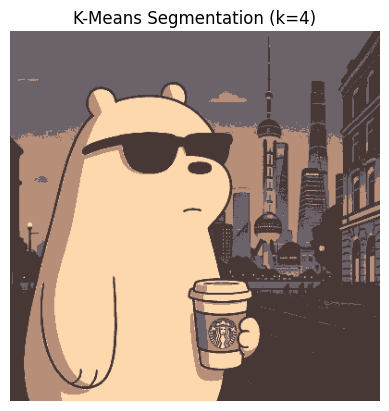

In [9]:
pixel_vals = img_rgb.reshape((-1, 3)).astype(np.float32)

k = 4
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
_, labels, centers = cv2.kmeans(pixel_vals, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

centers = np.uint8(centers)
kmeans_img = centers[labels.flatten()].reshape(img_rgb.shape)

plt.imshow(kmeans_img)
plt.title(f"K-Means Segmentation (k={k})")
plt.axis('off')
plt.show()

### Steps 8–9: Compare all segmentation outputs

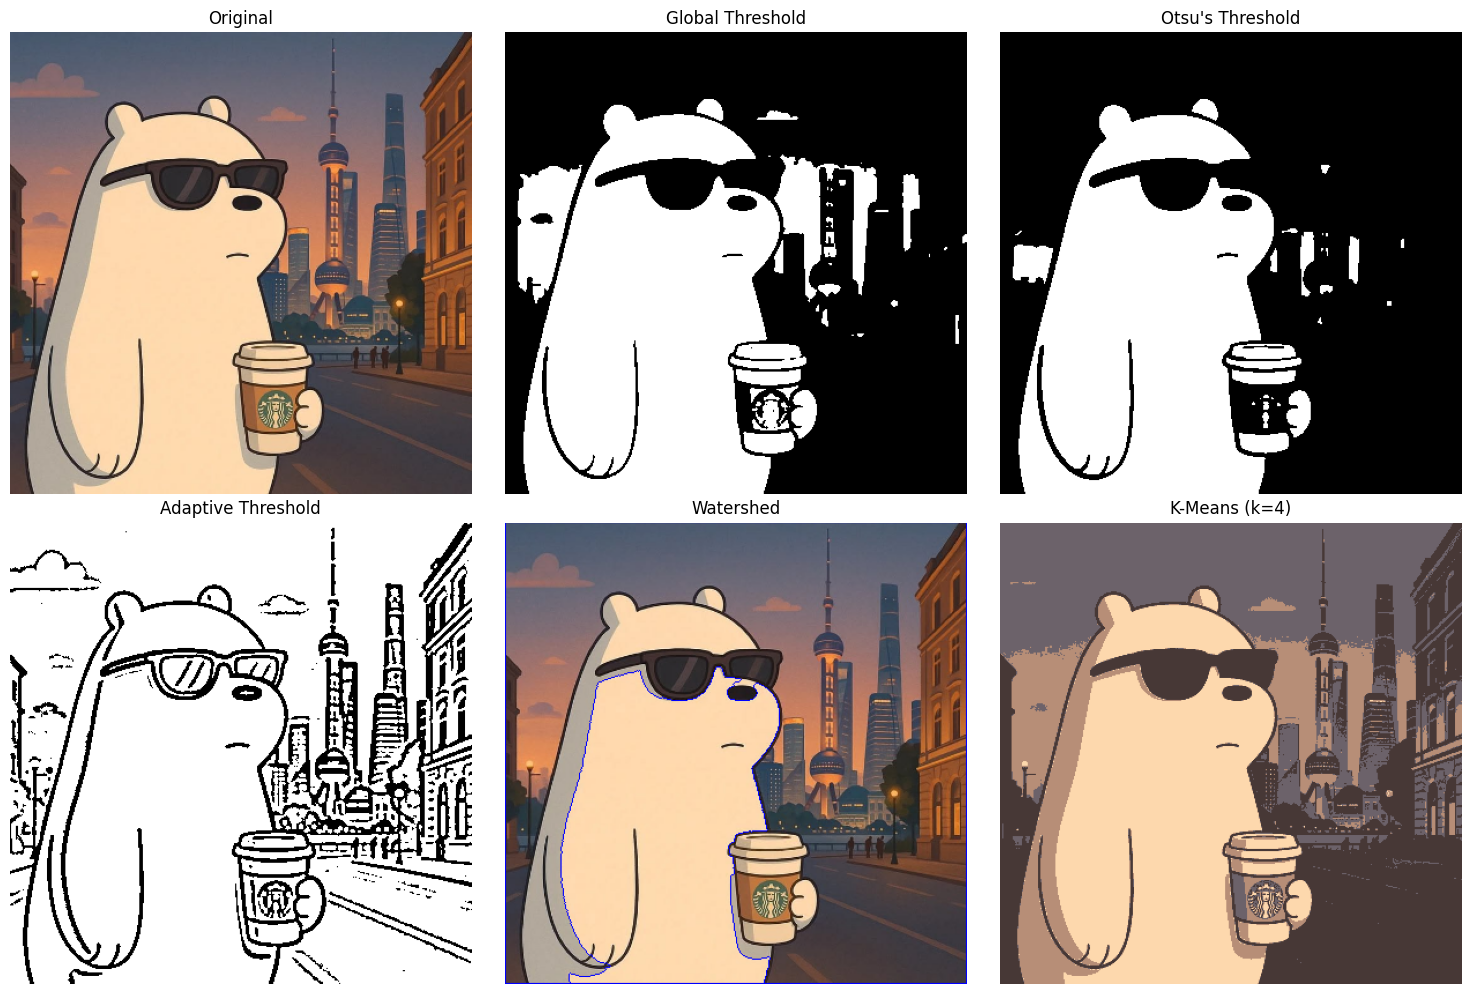

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
imgs = [img_rgb, global_thresh, otsu_thresh, adaptive_thresh,
        cv2.cvtColor(watershed_img, cv2.COLOR_BGR2RGB), kmeans_img]
titles = ["Original", "Global Threshold", "Otsu's Threshold",
          "Adaptive Threshold", "Watershed", "K-Means (k=4)"]
cmaps = [None, 'gray', 'gray', 'gray', None, None]

for ax, im, title, cmap in zip(axes.ravel(), imgs, titles, cmaps):
    ax.imshow(im, cmap=cmap)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

### Step 10: Observations & Summary

- **Global Thresholding** is fast but fails when illumination is uneven across the image, since it uses one fixed cutoff.
- **Otsu's Thresholding** automatically finds an optimal threshold from the histogram, working well for bimodal (clear foreground/background) images.
- **Adaptive Thresholding** computes a local threshold per neighborhood, handling uneven lighting much better than global methods.
- **Watershed Segmentation** successfully separates touching/overlapping objects by treating intensity as topography, useful where objects are clustered together.
- **K-Means Clustering** segments the image by color similarity rather than intensity boundaries, useful for images with multiple distinct color regions.
- Thresholding methods are computationally cheapest; Watershed and K-Means are more expensive but capture more complex structure (object boundaries, color regions).
- Segmentation choice should match the image type: simple bimodal images → Otsu; uneven lighting → adaptive; touching objects → watershed; color-based regions → K-Means.

---

## Questions

**Q1. What is image segmentation? Why is it considered a fundamental step in computer vision?**

**Ans:** Image segmentation is the process of partitioning an image into multiple meaningful regions or objects based on characteristics like intensity, color, or texture. It's fundamental because it isolates the region of interest from the background, simplifying and enabling accurate downstream tasks such as object detection, recognition, and scene understanding.

**Q2. Differentiate between Image Segmentation and Image Classification.**

**Ans:** Image classification assigns a single label to an entire image, describing what the image contains overall. Image segmentation goes further by partitioning the image into regions and assigning labels/boundaries at the pixel level, identifying exactly where each object or region is located within the image.

**Q3. Explain the working principle of Global Thresholding, Otsu's Thresholding, and Adaptive Thresholding.**

**Ans:** Global Thresholding applies one fixed intensity cutoff to the entire image, classifying pixels as foreground or background based on whether they exceed it. Otsu's Thresholding automatically calculates the optimal global threshold by analyzing the image histogram to minimize intra-class intensity variance (best for bimodal histograms). Adaptive Thresholding computes a different threshold for each local neighborhood based on surrounding pixel values, making it robust to images with uneven or varying illumination.

**Q4. What is the Watershed Algorithm? Why is it useful for separating overlapping objects?**

**Ans:** The Watershed Algorithm treats the grayscale image as a topographic surface, where pixel intensity represents elevation, and simulates flooding from marked regions until different "basins" meet, forming boundaries at the meeting points (watershed lines). It's useful for separating touching or overlapping objects because it can identify individual object boundaries even when objects are connected, unlike simple thresholding which would merge them into one blob.

**Q5. How is K-Means Clustering applied to image segmentation?**

**Ans:** Each pixel's color values (e.g., RGB) are treated as a data point in feature space, and K-Means groups these pixels into `k` clusters based on color similarity by iteratively assigning pixels to the nearest cluster center and updating centers. Each pixel is then replaced with its cluster's center color, producing an image segmented into `k` visually distinct color regions.

**Q6. Compare threshold-based segmentation and clustering-based segmentation techniques.**

**Ans:** Threshold-based segmentation (global/Otsu/adaptive) separates pixels based on a single intensity value or local intensity comparison, making it fast and simple but limited to intensity-based separation. Clustering-based segmentation (like K-Means) groups pixels based on multi-dimensional similarity (e.g., color), allowing it to capture more complex regions that aren't distinguishable by intensity alone, at the cost of higher computation.

**Q7. What challenges are encountered while segmenting images with complex backgrounds or varying illumination?**

**Ans:** Complex backgrounds can have intensity or color values overlapping with the foreground object, causing thresholding methods to misclassify pixels. Varying illumination causes the same object to have different intensities across the image, making a single global threshold ineffective and requiring more adaptive or robust techniques (adaptive thresholding, clustering, or learned models) to achieve accurate segmentation.

**Q8. Mention five real-world applications where image segmentation plays a critical role.**

**Ans:** (1) Medical imaging (tumor/organ segmentation in MRI/CT scans), (2) autonomous driving (segmenting roads, pedestrians, vehicles), (3) satellite image analysis (land-use/land-cover mapping), (4) industrial quality inspection (defect region isolation), and (5) agriculture (segmenting crops/weeds in aerial imagery).

**Q9. How does image segmentation improve the performance of object detection and image recognition systems?**

**Ans:** By isolating relevant regions/objects from the background and irrelevant clutter, segmentation reduces the search space and noise that detection/recognition algorithms need to process, allowing them to focus computation and analysis on the actual object boundaries — improving both accuracy and efficiency.

**Q10. Compare traditional image segmentation techniques with deep learning-based segmentation methods such as U-Net and Mask R-CNN.**

**Ans:** Traditional techniques (thresholding, watershed, K-Means) rely on handcrafted rules based on intensity, color, or geometry, requiring no training data and being computationally lightweight, but they struggle with complex, cluttered, or highly variable real-world scenes. Deep learning-based methods like U-Net (pixel-wise semantic segmentation) and Mask R-CNN (instance segmentation) learn segmentation patterns directly from large labeled datasets, achieving much higher accuracy on complex scenes, but require significant training data, computational resources, and lack the interpretability of traditional methods.